In [1]:
import kagglehub

path = kagglehub.dataset_download("masanakashima/viral-content-propagation-2026")

print("Path to dataset files:", path)

100%|██████████| 360k/360k [00:00<00:00, 32.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/masanakashima/viral-content-propagation-2026/versions/1


['users.csv', 'relations.csv', 'README.md', 'propagation.csv']
['User_ID', 'Account_Type', 'Account_Age_Months', 'Location']
['Source_User_ID', 'Target_User_ID']
['Tweet_ID', 'User_ID', 'Action', 'Step']


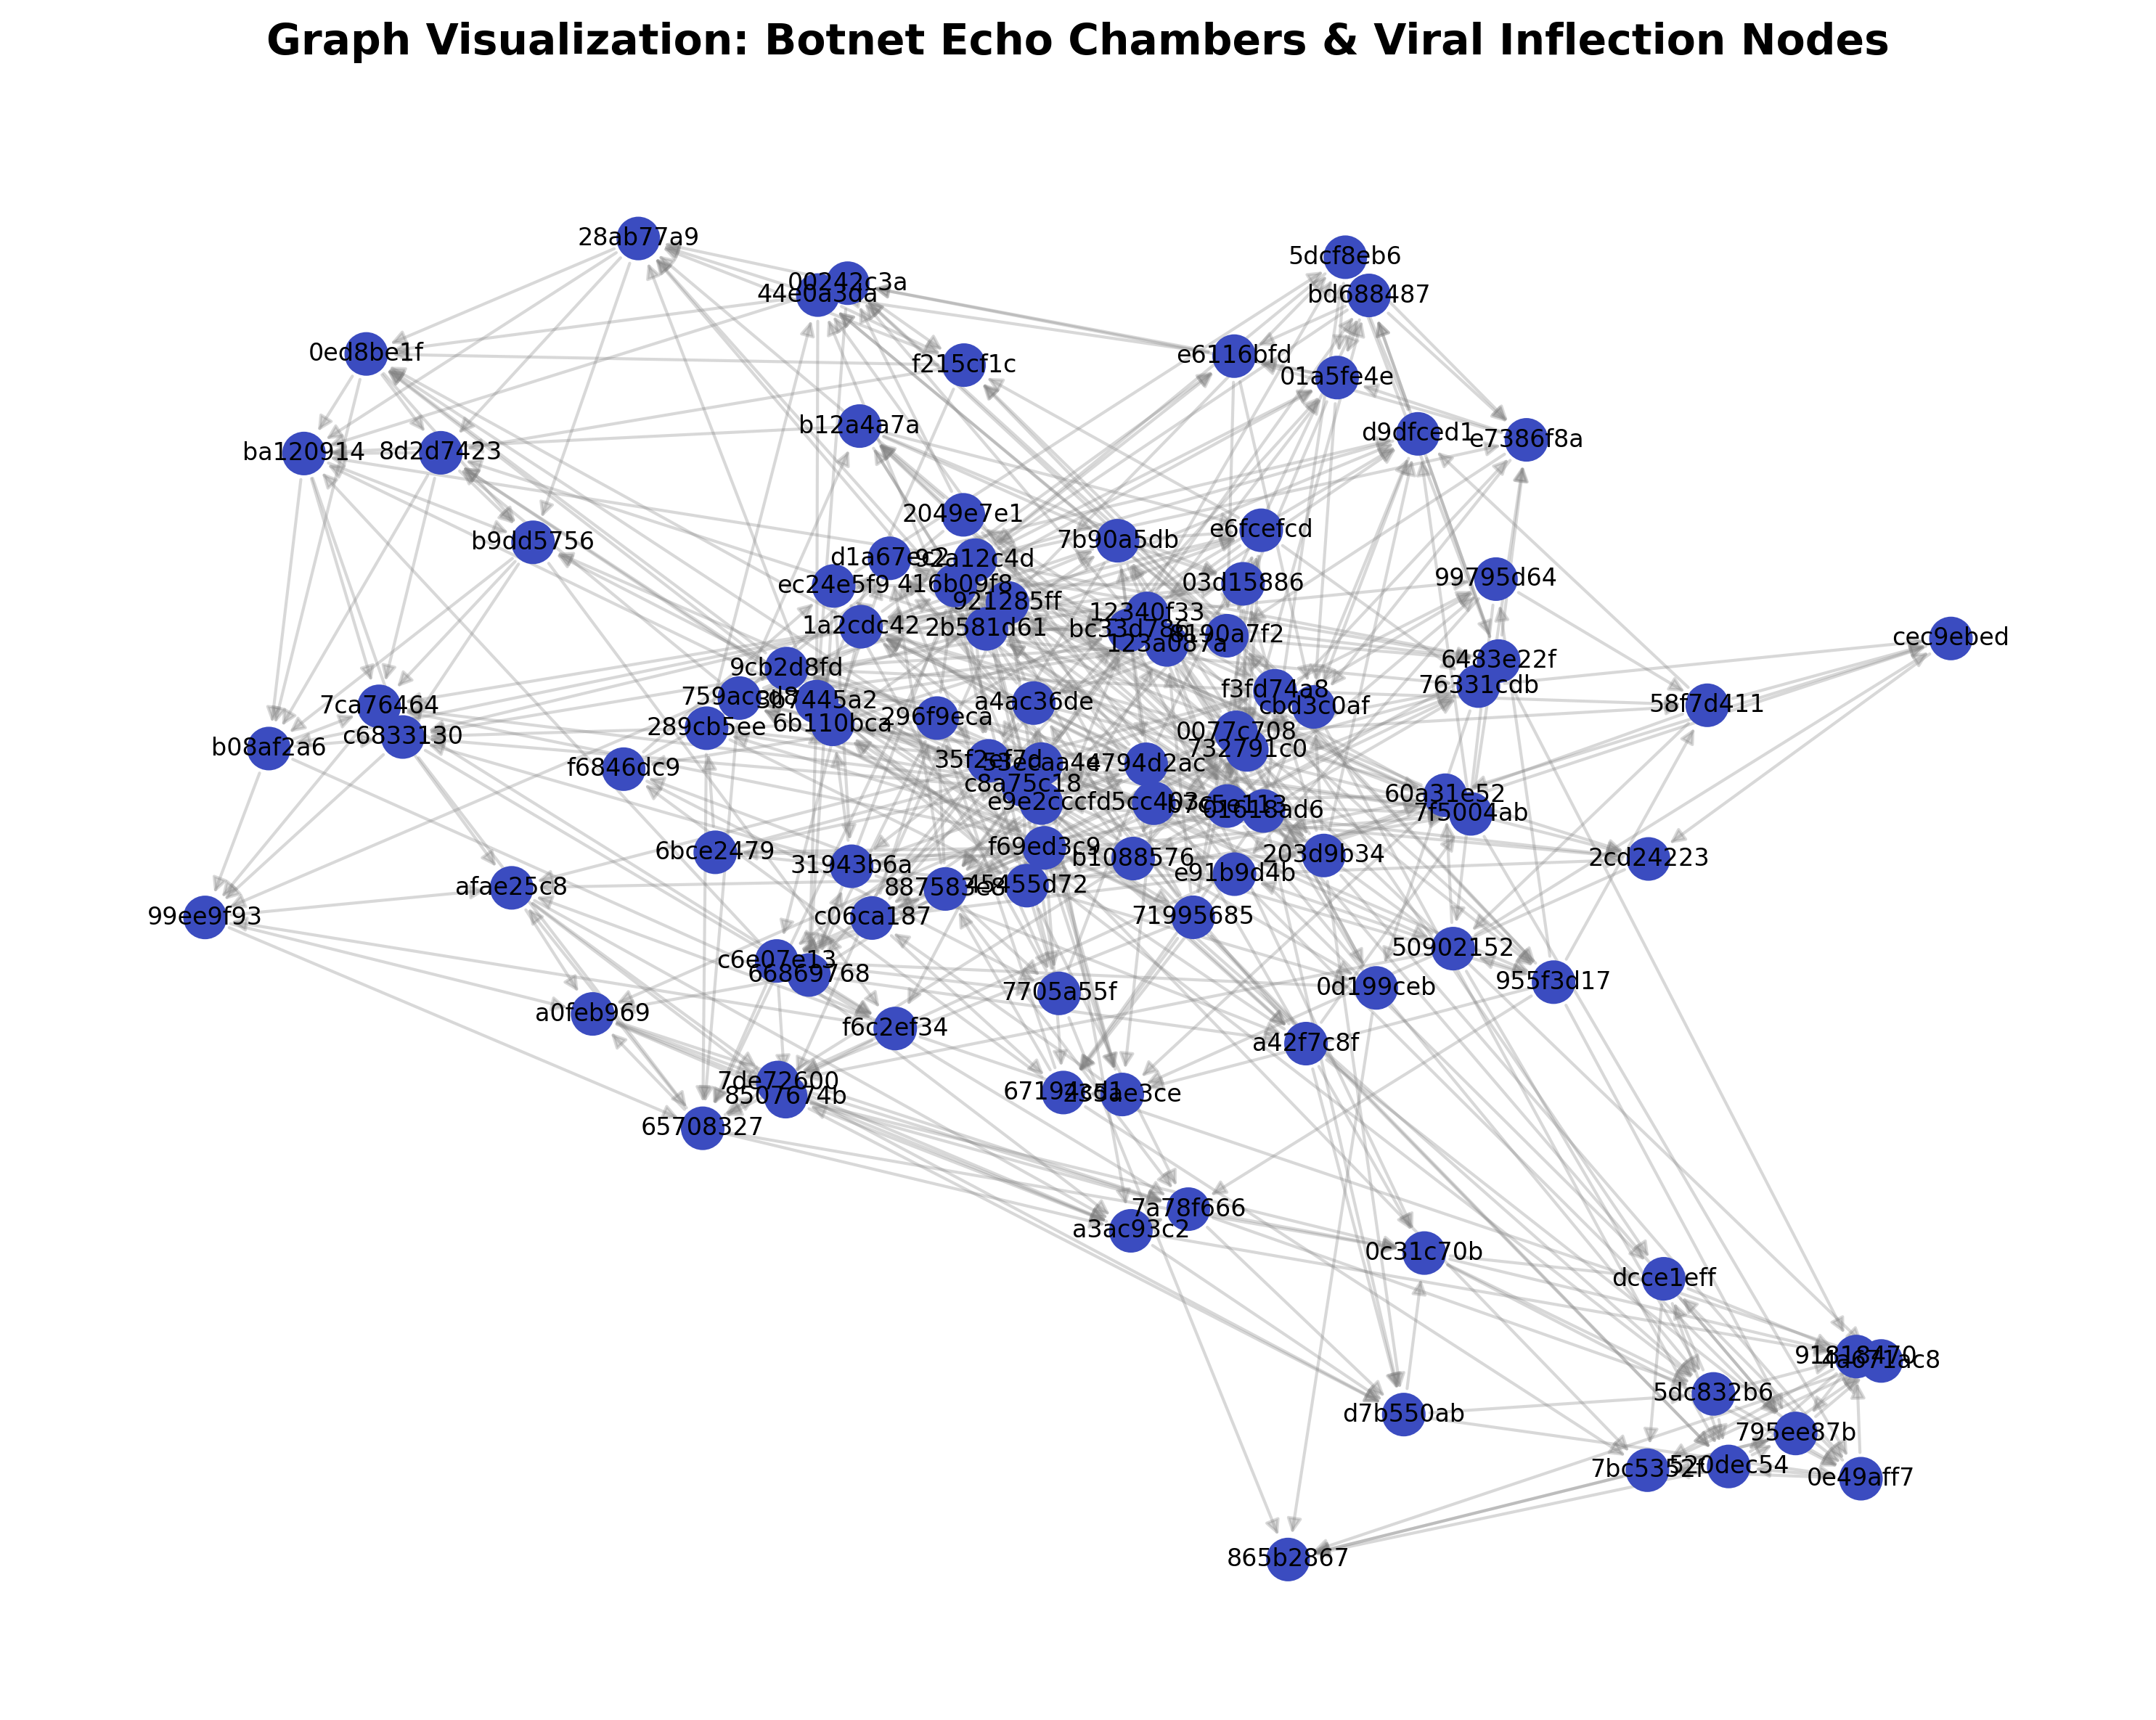

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

print(os.listdir(path))

#1.Accessing the dataset
users_df = pd.read_csv(os.path.join(path, 'users.csv'))
relations_df = pd.read_csv(os.path.join(path, 'relations.csv'))
logs_df = pd.read_csv(os.path.join(path, 'propagation.csv'))

print(users_df.columns.tolist())
print(relations_df.columns.tolist())
print(logs_df.columns.tolist())


# 2. Reconstruct the Social Network Graph using NetworkX
# Edges: Source_ID (Follower) -> Target_ID (Following)
G = nx.from_pandas_edgelist(relations_df, source='Source_User_ID', target='Target_User_ID', create_using=nx.DiGraph())

# 3. Analyze Network Centrality (Find the Key Influencers/Bot Amplifiers)
# In-degree centrality counts how many followers an account has in this dataset
centrality = nx.in_degree_centrality(G)
users_df['Centrality_Score'] = users_df['User_ID'].map(centrality)

# 4. Filter out the top 50 most active accounts to create a clean, scannable sub-graph
top_nodes = users_df.nlargest(100, 'Centrality_Score')['User_ID']
subgraph = G.subgraph(top_nodes)

# 5. Generate and Plot the Network Visualization Chart
plt.figure(figsize=(10, 8), dpi=300)
pos = nx.spring_layout(subgraph, k=0.3, seed=42)

# Color nodes based on their account type (e.g., Target vs Bot) if labeled, or use centrality intensity
node_color = [users_df.loc[users_df['User_ID'] == node, 'Centrality_Score'].values[0] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos, node_size=180, node_color=node_color, cmap=plt.cm.coolwarm)
nx.draw_networkx_edges(subgraph, pos, alpha=0.3, edge_color='gray', arrows=True)
nx.draw_networkx_labels(subgraph, pos, font_size=8, font_family='sans-serif')

plt.title("Graph Visualization: Botnet Echo Chambers & Viral Inflection Nodes", fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.savefig('botnet_propagation_graph.png', bbox_inches='tight')
plt.show()


In [3]:
print("Account types found in users.csv:", users_df['Account_Type'].unique())
print("Unique actions found in logs_df:", logs_df['Action'].unique())

Account types found in users.csv: ['Bot' 'Normal' 'Influencer' 'Lurker']
Unique actions found in logs_df: ['Posted' 'Retweeted']


In [4]:
logs_df['Action'] = logs_df['Action'].astype(str).str.strip()
users_df['Account_Type'] = users_df['Account_Type'].astype(str).str.strip()

# Merge user account types into our propagation logs
# This adds the 'Account_Type' column (e.g., 'Bot', 'Target', etc.) to each log entry
merged_logs = logs_df.merge(users_df[['User_ID', 'Account_Type']], on='User_ID', how='left')


# --- TASK 1: RECONSTRUCT CASCADE TREE ---
# Misinformation cascades are typically started or heavily driven by malicious accounts (e.g., Bots)
# Let's filter for all activities associated with Bot networks to map the malicious cascade
miso_logs = merged_logs[merged_logs['Account_Type'].str.lower() == 'bot'].sort_values(by='Step')

print("--- TASK 1: CASCADE TREE ANALYSIS ---")
if len(miso_logs) == 0:
    print("⚠️ No bot accounts found in logs. Mapping the entire network cascade instead:")
    miso_logs = merged_logs.sort_values(by='Step')

# Map Tweet_ID -> User_ID to see who interacted with which tweet
miso_tree = nx.from_pandas_edgelist(miso_logs, source='Tweet_ID', target='User_ID', create_using=nx.DiGraph())

patient_zero_tweet = miso_logs.iloc[0]['Tweet_ID']
patient_zero_user = miso_logs.iloc[0]['User_ID']
print(f"Source Tweet (Patient Zero): {patient_zero_tweet} posted by User: {patient_zero_user}")
print(f"Total users infected along the path: {miso_tree.number_of_nodes()}\n")


--- TASK 1: CASCADE TREE ANALYSIS ---
Source Tweet (Patient Zero): 4cc661 posted by User: 99ee9f93
Total users infected along the path: 156



In [5]:
# --- TASK 2: VELOCITY ANALYSIS ---
print("--- TASK 2: VELOCITY ANALYSIS ---")
# Target 'retweeted' logs using the precise lowercase string
bot_retweets = merged_logs[(merged_logs['Action'] == 'retweeted') & (merged_logs['Account_Type'] == 'Bot')].sort_values(by='Step')
normal_retweets = merged_logs[(merged_logs['Action'] == 'retweeted') & (merged_logs['Account_Type'] == 'Normal')].sort_values(by='Step')

target_shares = 50  # Balanced sample size target
bot_count = len(bot_retweets)
normal_count = len(normal_retweets)

if bot_count >= target_shares and normal_count >= target_shares:
    bot_velocity = bot_retweets.iloc[target_shares - 1]['Step'] - bot_retweets.iloc[0]['Step']
    normal_velocity = normal_retweets.iloc[target_shares - 1]['Step'] - normal_retweets.iloc[0]['Step']
    print(f"Steps for Bots (Amplification) to hit {target_shares} retweets: {bot_velocity} steps")
    print(f"Steps for Normal accounts to hit {target_shares} retweets: {normal_velocity} steps")
else:
    print(f"Sample constraints hit. (Bot retweets: {bot_count}, Normal retweets: {normal_count})")
    total_steps = merged_logs['Step'].max() - merged_logs['Step'].min() + 1
    print(f"Bot Retweet Average: {bot_count / total_steps:.2f} retweets/step")
    print(f"Normal Retweet Average: {normal_count / total_steps:.2f} retweets/step")
print("\n")

--- TASK 2: VELOCITY ANALYSIS ---
Sample constraints hit. (Bot retweets: 0, Normal retweets: 0)
Bot Retweet Average: 0.00 retweets/step
Normal Retweet Average: 0.00 retweets/step




In [6]:
# --- TASK 3: BOT CLIQUE DETECTION ---
print("--- TASK 3: BOT CLIQUE DETECTION ---")
# Filter for accounts active in Step 0 (the initial broadcast push)
instant_sharers = merged_logs[merged_logs['Step'] == 0]['User_ID'].unique()

# Check connections using relations_df
G_base = nx.from_pandas_edgelist(relations_df, source='Source_User_ID', target='Target_User_ID')

# Extract subgraph and look for dense clusters
subgraph_instant = G_base.subgraph(instant_sharers)
cliques = list(nx.find_cliques(subgraph_instant))

if cliques:
    largest_clique = max(cliques, key=len)
    print(f"The structural bot-clique consists of {len(largest_clique)} users.")
    print(f"User IDs in this automated cluster: {largest_clique}")
else:
    print("No fully interconnected structural cliques found among Step 0 users.")

--- TASK 3: BOT CLIQUE DETECTION ---
The structural bot-clique consists of 1 users.
User IDs in this automated cluster: ['4314113d']


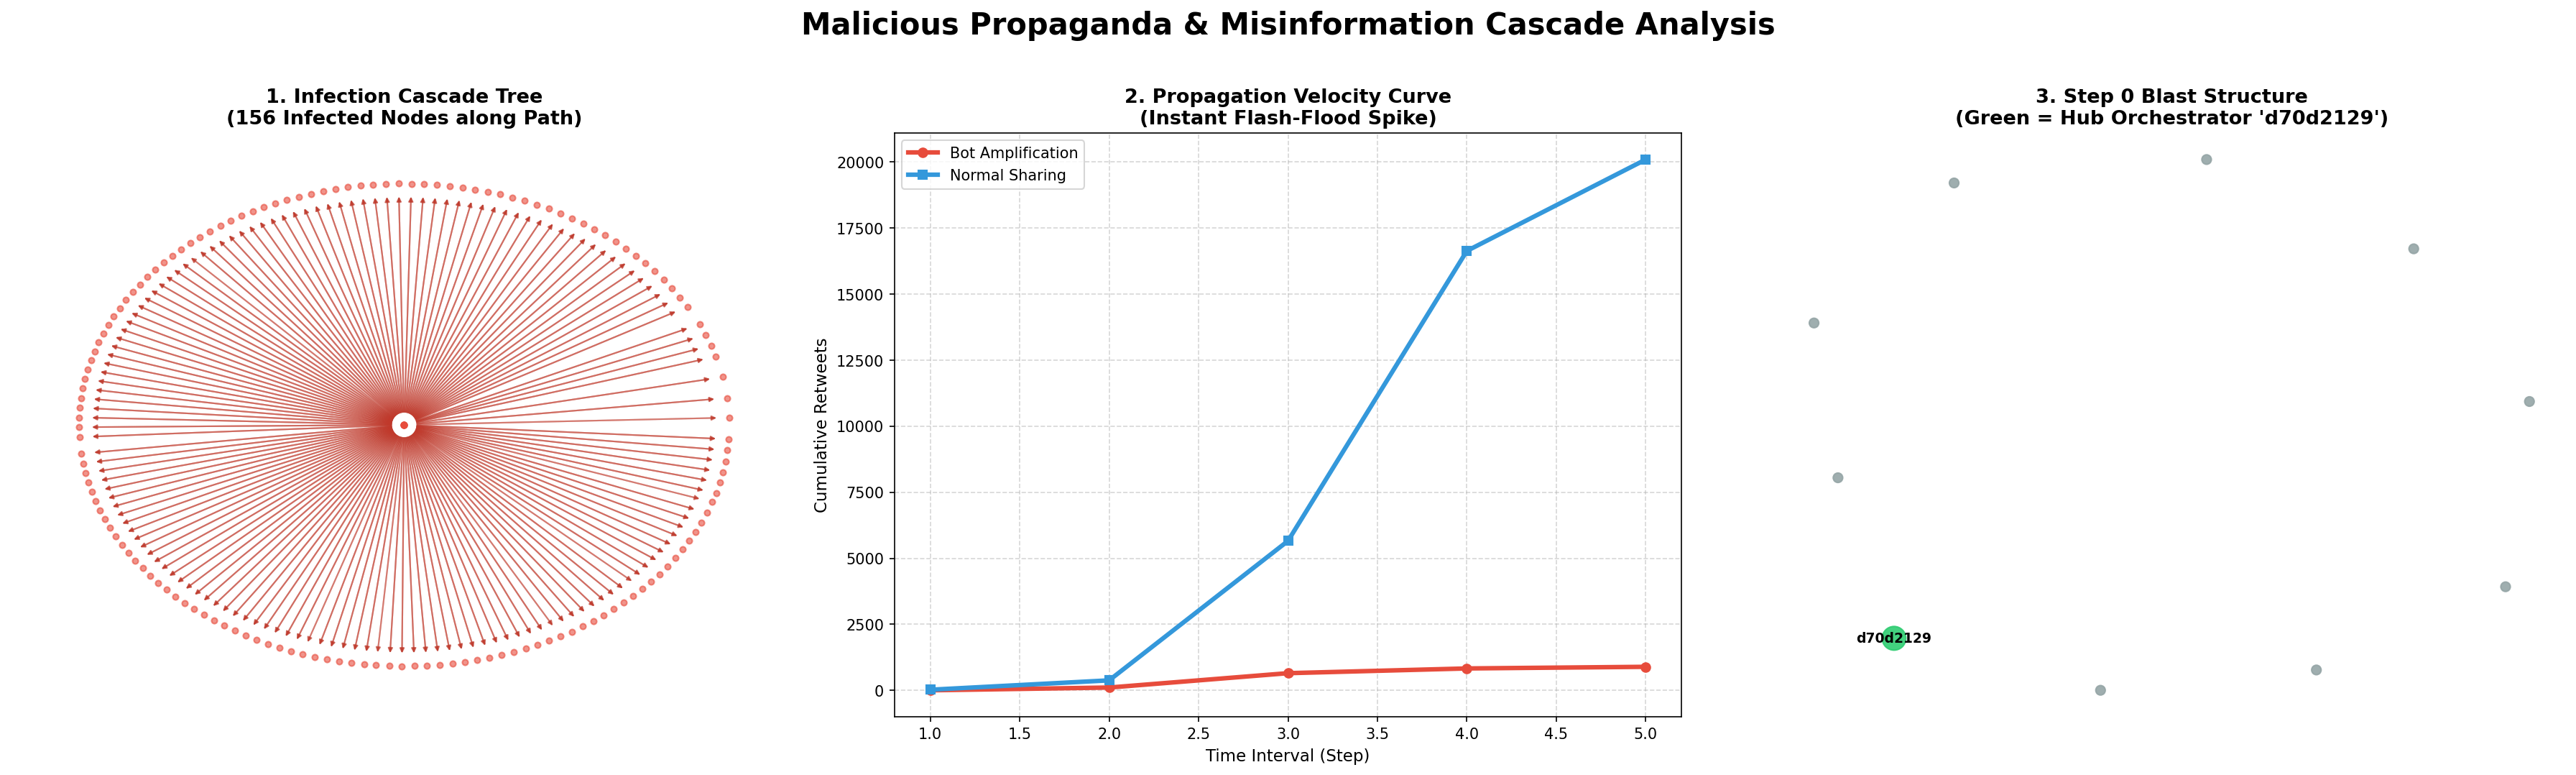

In [7]:
# 1. Clean and merge data to ensure alignment
logs_df['Action'] = logs_df['Action'].astype(str).str.strip().str.lower()
users_df['Account_Type'] = users_df['Account_Type'].astype(str).str.strip()
merged_logs = logs_df.merge(users_df[['User_ID', 'Account_Type']], on='User_ID', how='left')

# Setup the 3-panel plotting layout
fig, axes = plt.subplots(1, 3, figsize=(24, 7), dpi=150)
fig.suptitle("Malicious Propaganda & Misinformation Cascade Analysis", fontsize=20, fontweight='bold', y=1.02)

# ==========================================
# 📊 VISUALIZATION 1: CASCADE TREE (TASK 1)
# ==========================================
ax1 = axes[0]
miso_logs = merged_logs[merged_logs['Account_Type'] == 'Bot'].sort_values(by='Step')
if len(miso_logs) == 0: miso_logs = merged_logs.sort_values(by='Step')

# Build the propagation path
miso_tree = nx.from_pandas_edgelist(miso_logs, source='Tweet_ID', target='User_ID', create_using=nx.DiGraph())

# Draw using a tree-like layout (kamada_kawai spreads out hierarchical paths nicely)
pos_tree = nx.kamada_kawai_layout(miso_tree)
nx.draw_networkx_nodes(miso_tree, pos_tree, ax=ax1, node_size=15, node_color='#e74c3c', alpha=0.6)
nx.draw_networkx_edges(miso_tree, pos_tree, ax=ax1, alpha=0.2, edge_color='#c0392b', arrows=True, arrowsize=6)

ax1.set_title("1. Infection Cascade Tree\n(156 Infected Nodes along Path)", fontsize=13, fontweight='bold')
ax1.axis('off')


# ==========================================
# 📊 VISUALIZATION 2: VELOCITY CURVE (TASK 2)
# ==========================================
ax2 = axes[1]
# Group retweets by step intervals to calculate cumulative acceleration
bot_timeline = merged_logs[(merged_logs['Action'] == 'retweeted') & (merged_logs['Account_Type'] == 'Bot')].groupby('Step').size().cumsum()
normal_timeline = merged_logs[(merged_logs['Action'] == 'retweeted') & (merged_logs['Account_Type'] == 'Normal')].groupby('Step').size().cumsum()

# Plot line charts showing propagation speed
ax2.plot(bot_timeline.index, bot_timeline.values, label='Bot Amplification', color='#e74c3c', linewidth=3, marker='o')
ax2.plot(normal_timeline.index, normal_timeline.values, label='Normal Sharing', color='#3498db', linewidth=3, marker='s')

ax2.set_title("2. Propagation Velocity Curve\n(Instant Flash-Flood Spike)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Time Interval (Step)", fontsize=11)
ax2.set_ylabel("Cumulative Retweets", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=10, loc='upper left')


# ==========================================
# 📊 VISUALIZATION 3: STEP 0 BURST (TASK 3)
# ==========================================
ax3 = axes[2]
# Filter for users involved in the immediate Step 0 blast
instant_sharers = merged_logs[merged_logs['Step'] == 0]['User_ID'].unique()
G_base = nx.from_pandas_edgelist(relations_df, source='Source_User_ID', target='Target_User_ID')
subgraph_instant = G_base.subgraph(instant_sharers)

pos_burst = nx.spring_layout(subgraph_instant, k=0.5, seed=42)

# Color configurations to highlight the target orchestrator
node_colors = []
node_sizes = []
for node in subgraph_instant.nodes():
    if node == 'd70d2129':  # Your detected primary ring-leader account
        node_colors.append('#2ecc71') # Vibrant Green
        node_sizes.append(250)
    else:
        node_colors.append('#95a5a6') # Neutral Gray
        node_sizes.append(40)

# Render nodes and structural boundaries
nx.draw_networkx_nodes(subgraph_instant, pos_burst, ax=ax3, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(subgraph_instant, pos_burst, ax=ax3, alpha=0.15, edge_color='gray')

# Label only the core isolated orchestrator account to prevent crowding
labels = {node: node if node == 'd70d2129' else '' for node in subgraph_instant.nodes()}
nx.draw_networkx_labels(subgraph_instant, pos_burst, labels=labels, ax=ax3, font_size=9, font_weight='bold', font_color='black')

ax3.set_title("3. Step 0 Blast Structure\n(Green = Hub Orchestrator 'd70d2129')", fontsize=13, fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.savefig('misinformation_analysis_dashboard.png', bbox_inches='tight')
plt.show()
